In [2]:
# ========================================
# Imports
# ========================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/SEAID_Framework"
)

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "figures" / "exploration"
MODEL_DIR = PROJECT_ROOT / "models"

for folder in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURE_DIR,
    MODEL_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Project folder:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)

Project folder: /content/drive/MyDrive/SEAID_Framework
Raw data folder: /content/drive/MyDrive/SEAID_Framework/data/raw


In [5]:
!pip install -q kagglehub

In [6]:
import kagglehub
from pathlib import Path
import shutil

In [7]:
download_path = kagglehub.dataset_download(
    "anlgrbz/student-demographics-online-education-dataoulad"
)

download_path = Path(download_path)

print(
    "Kaggle download folder:",
    download_path
)

Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.
Kaggle download folder: /kaggle/input/student-demographics-online-education-dataoulad


In [8]:
import os
import matplotlib.pyplot as plt

os.makedirs("../figures", exist_ok=True)

def save_figure(filename):
    plt.tight_layout()
    plt.savefig(
        f"../figures/{filename}",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

In [9]:
import platform
print(platform.platform())

Linux-6.6.122+-x86_64-with-glibc2.35


In [10]:
try:
    from google.colab import drive
    print("Google Colab environment detected.")
except ImportError:
    print("This is not Google Colab.")

Google Colab environment detected.


In [11]:
csv_files = list(
    download_path.rglob("*.csv")
)

print(
    f"Found {len(csv_files)} CSV files."
)

for source_file in csv_files:
    destination_file = (
        RAW_DATA_DIR
        / source_file.name
    )

    shutil.copy2(
        source_file,
        destination_file
    )

    print(
        "Copied:",
        source_file.name
    )

Found 7 CSV files.
Copied: studentRegistration.csv
Copied: studentAssessment.csv
Copied: studentInfo.csv
Copied: studentVle.csv
Copied: vle.csv
Copied: assessments.csv
Copied: courses.csv


In [12]:
drive_files = sorted(
    RAW_DATA_DIR.glob("*.csv")
)

for file in drive_files:
    print(file.name)

assessments.csv
courses.csv
studentAssessment.csv
studentInfo.csv
studentRegistration.csv
studentVle.csv
vle.csv


In [13]:
import pandas as pd

student_info = pd.read_csv(
    RAW_DATA_DIR / "studentInfo.csv"
)

student_assessment = pd.read_csv(
    RAW_DATA_DIR / "studentAssessment.csv"
)

student_registration = pd.read_csv(
    RAW_DATA_DIR / "studentRegistration.csv"
)

student_vle = pd.read_csv(
    RAW_DATA_DIR / "studentVle.csv"
)

vle = pd.read_csv(
    RAW_DATA_DIR / "vle.csv"
)

assessments = pd.read_csv(
    RAW_DATA_DIR / "assessments.csv"
)

courses = pd.read_csv(
    RAW_DATA_DIR / "courses.csv"
)

print("All OULAD tables loaded successfully.")

All OULAD tables loaded successfully.


In [14]:
tables = {
    "student_info": student_info,
    "student_assessment": student_assessment,
    "student_registration": student_registration,
    "student_vle": student_vle,
    "vle": vle,
    "assessments": assessments,
    "courses": courses
}

for name, df in tables.items():
    print(
        f"{name}: "
        f"{df.shape[0]:,} rows, "
        f"{df.shape[1]} columns"
    )

student_info: 32,593 rows, 12 columns
student_assessment: 173,912 rows, 5 columns
student_registration: 32,593 rows, 5 columns
student_vle: 10,655,280 rows, 6 columns
vle: 6,364 rows, 6 columns
assessments: 206 rows, 6 columns
courses: 22 rows, 3 columns


In [15]:
student_info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [16]:
# Check the structure of the student information table

student_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


In [17]:
# Review the column names

student_info.columns.tolist()

['code_module',
 'code_presentation',
 'id_student',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'final_result']

In [18]:
table_summary = pd.DataFrame(
    {
        "table": list(tables.keys()),
        "rows": [df.shape[0] for df in tables.values()],
        "columns": [df.shape[1] for df in tables.values()]
    }
)

table_summary

,table,rows,columns
0,student_info,32593,12
1,student_assessment,173912,5
2,student_registration,32593,5
3,student_vle,10655280,6
4,vle,6364,6
5,assessments,206,6
6,courses,22,3


In [19]:
missing_summary = pd.DataFrame(
    {
        "missing_count": student_info.isna().sum(),
        "missing_percent": (
            student_info.isna().mean() * 100
        ).round(2)
    }
).sort_values(
    by="missing_percent",
    ascending=False
)

missing_summary

,missing_count,missing_percent
imd_band,1111,3.41
code_module,0,0.00
id_student,0,0.00
code_presentation,0,0.00
gender,0,0.00
region,0,0.00
highest_education,0,0.00
age_band,0,0.00
num_of_prev_attempts,0,0.00
studied_credits,0,0.00


In [20]:
final_result_counts = (
    student_info["final_result"]
    .value_counts()
)

final_result_counts

,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


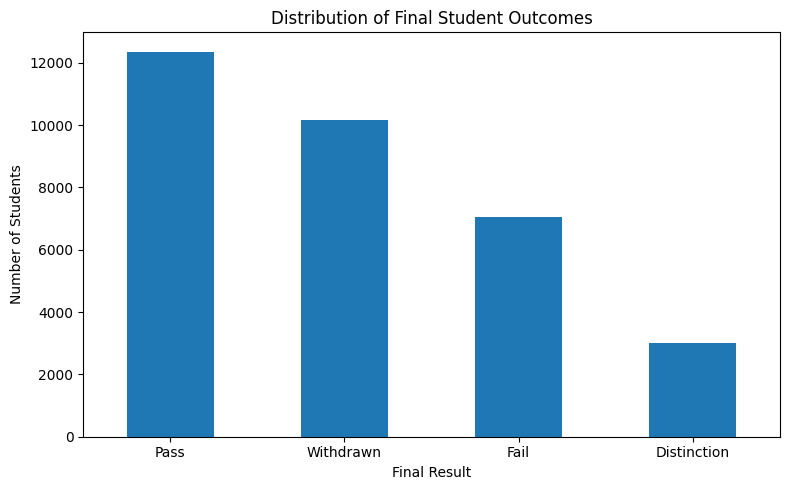

In [21]:
plt.figure(figsize=(8, 5))

final_result_counts.plot(
    kind="bar"
)

plt.title(
    "Distribution of Final Student Outcomes"
)

plt.xlabel("Final Result")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

save_figure(
    "final_result_distribution.png"
)

In [22]:
# Aggregate total VLE activity for each student-course presentation

student_engagement = (
    student_vle
    .groupby(
        [
            "code_module",
            "code_presentation",
            "id_student"
        ],
        as_index=False
    )["sum_click"]
    .sum()
    .rename(
        columns={
            "sum_click": "total_clicks"
        }
    )
)

student_engagement.head()

,code_module,code_presentation,id_student,total_clicks
0,AAA,2013J,11391,934
1,AAA,2013J,28400,1435
2,AAA,2013J,30268,281
3,AAA,2013J,31604,2158
4,AAA,2013J,32885,1034


In [23]:
print(
    f"Engagement summary: "
    f"{student_engagement.shape[0]:,} rows, "
    f"{student_engagement.shape[1]} columns"
)

Engagement summary: 29,228 rows, 4 columns


In [24]:
student_exploration = student_info.merge(
    student_engagement,
    on=[
        "code_module",
        "code_presentation",
        "id_student"
    ],
    how="left"
)

student_exploration["total_clicks"] = (
    student_exploration["total_clicks"]
    .fillna(0)
)

student_exploration.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0


In [25]:
print(
    "Original student records:",
    f"{student_info.shape[0]:,}"
)

print(
    "Merged student records:",
    f"{student_exploration.shape[0]:,}"
)

Original student records: 32,593
Merged student records: 32,593


In [26]:
student_exploration["total_clicks"].describe()

,total_clicks
count,32593.000000
mean,1215.141257
std,1692.604449
min,0.000000
25%,142.000000
50%,602.000000
75%,1585.000000
max,24139.000000


In [27]:
engagement_by_result = (
    student_exploration
    .groupby("final_result")["total_clicks"]
    .agg(
        student_count="count",
        mean_clicks="mean",
        median_clicks="median"
    )
    .round(2)
    .sort_values(
        by="mean_clicks",
        ascending=False
    )
)

engagement_by_result

,student_count,mean_clicks,median_clicks
final_result,,,
Distinction,3024,2666.76,1896.0
Pass,12361,1921.81,1343.0
Fail,7052,651.85,317.0
Withdrawn,10156,313.95,89.0


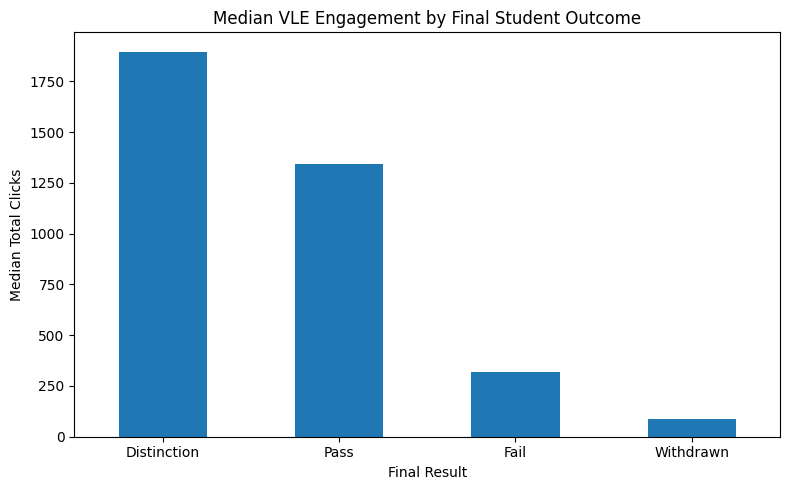

In [28]:
median_clicks_by_result = (
    student_exploration
    .groupby("final_result")["total_clicks"]
    .median()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(8, 5))

median_clicks_by_result.plot(
    kind="bar"
)

plt.title(
    "Median VLE Engagement by Final Student Outcome"
)

plt.xlabel("Final Result")
plt.ylabel("Median Total Clicks")
plt.xticks(rotation=0)

save_figure(
    "median_engagement_by_final_result.png"
)

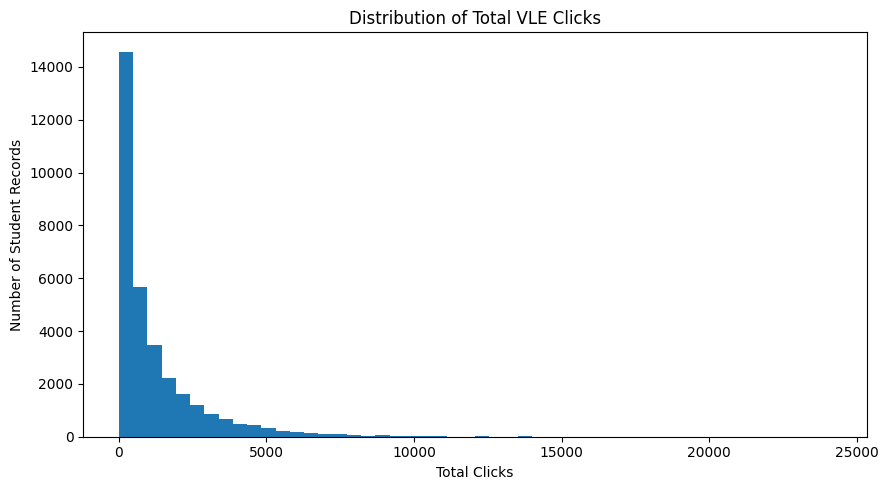

In [29]:
plt.figure(figsize=(9, 5))

plt.hist(
    student_exploration["total_clicks"],
    bins=50
)

plt.title(
    "Distribution of Total VLE Clicks"
)

plt.xlabel("Total Clicks")
plt.ylabel("Number of Student Records")

save_figure(
    "total_clicks_distribution.png"
)

In [30]:
student_exploration["log_total_clicks"] = np.log1p(
    student_exploration["total_clicks"]
)

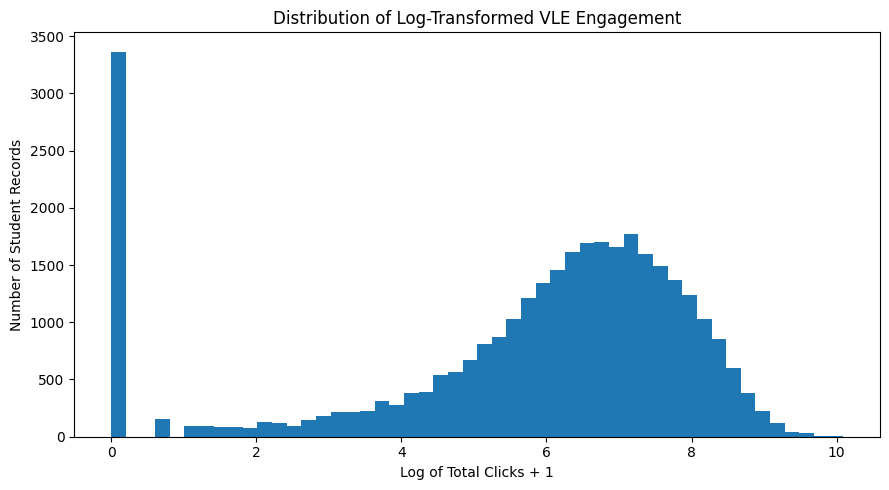

In [31]:
plt.figure(figsize=(9, 5))

plt.hist(
    student_exploration["log_total_clicks"],
    bins=50
)

plt.title(
    "Distribution of Log-Transformed VLE Engagement"
)

plt.xlabel("Log of Total Clicks + 1")
plt.ylabel("Number of Student Records")

save_figure(
    "log_total_clicks_distribution.png"
)

In [32]:
education_summary = (
    student_exploration["highest_education"]
    .value_counts(dropna=False)
)

education_summary

,count
highest_education,
A Level or Equivalent,14045
Lower Than A Level,13158
HE Qualification,4730
No Formal quals,347
Post Graduate Qualification,313


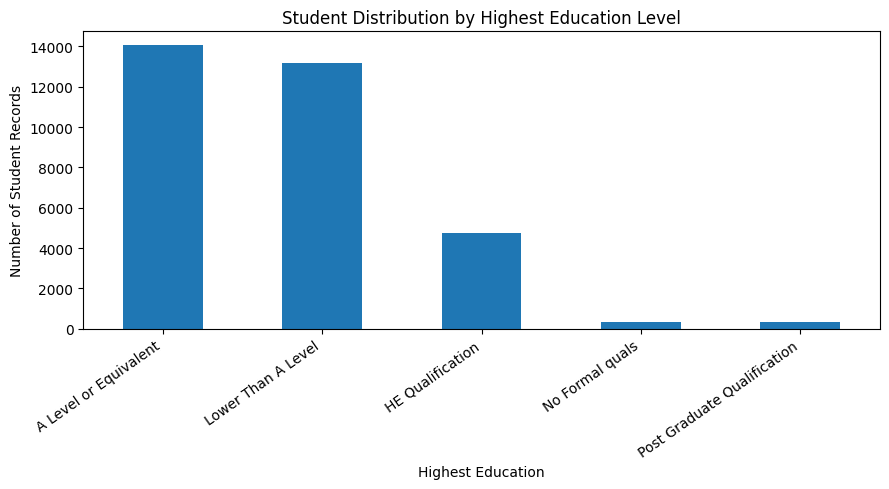

In [33]:
plt.figure(figsize=(9, 5))

education_summary.plot(
    kind="bar"
)

plt.title(
    "Student Distribution by Highest Education Level"
)

plt.xlabel("Highest Education")
plt.ylabel("Number of Student Records")
plt.xticks(rotation=35, ha="right")

save_figure(
    "highest_education_distribution.png"
)

In [34]:
education_outcomes = pd.crosstab(
    student_exploration["highest_education"],
    student_exploration["final_result"],
    normalize="index"
).mul(100).round(2)

education_outcomes

final_result,Distinction,Fail,Pass,Withdrawn
highest_education,,,,
A Level or Equivalent,10.65,19.27,41.38,28.69
HE Qualification,14.74,16.70,41.44,27.12
Lower Than A Level,5.53,26.04,33.33,35.11
No Formal quals,4.61,27.38,25.07,42.94
Post Graduate Qualification,28.12,10.86,37.38,23.64


In [35]:
imd_summary = (
    student_exploration["imd_band"]
    .value_counts(dropna=False)
    .sort_index()
)

imd_summary

,count
imd_band,
0-10%,3311
10-20,3516
20-30%,3654
30-40%,3539
40-50%,3256
50-60%,3124
60-70%,2905
70-80%,2879
80-90%,2762


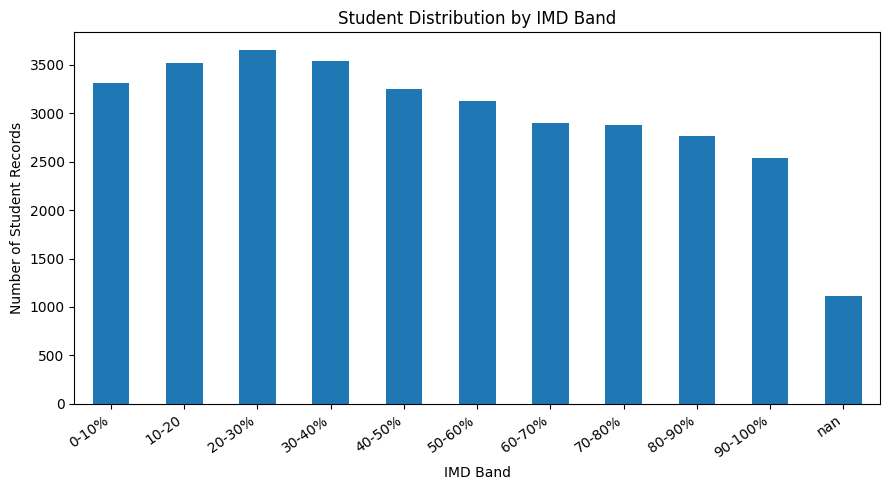

In [36]:
plt.figure(figsize=(9, 5))

imd_summary.plot(
    kind="bar"
)

plt.title(
    "Student Distribution by IMD Band"
)

plt.xlabel("IMD Band")
plt.ylabel("Number of Student Records")
plt.xticks(rotation=35, ha="right")

save_figure(
    "imd_band_distribution.png"
)

In [37]:
student_exploration["success"] = (
    student_exploration["final_result"]
    .isin(["Pass", "Distinction"])
    .astype(int)
)

In [38]:
success_by_imd = (
    student_exploration
    .groupby("imd_band", dropna=False)["success"]
    .agg(
        student_count="count",
        success_rate="mean"
    )
)

success_by_imd["success_rate"] = (
    success_by_imd["success_rate"] * 100
).round(2)

success_by_imd

,student_count,success_rate
imd_band,,
0-10%,3311,35.16
10-20,3516,38.62
20-30%,3654,40.75
30-40%,3539,46.91
40-50%,3256,46.59
50-60%,3124,48.78
60-70%,2905,51.91
70-80%,2879,51.51
80-90%,2762,54.06


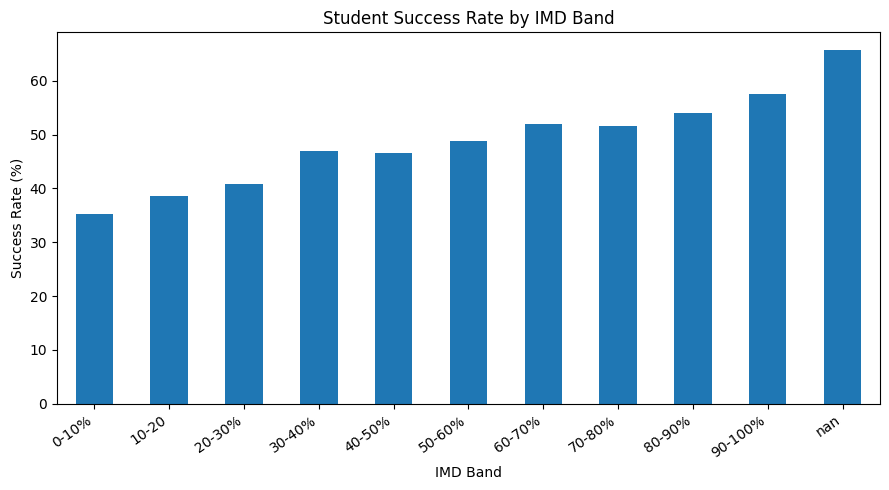

In [39]:
plt.figure(figsize=(9, 5))

success_by_imd["success_rate"].plot(
    kind="bar"
)

plt.title(
    "Student Success Rate by IMD Band"
)

plt.xlabel("IMD Band")
plt.ylabel("Success Rate (%)")
plt.xticks(rotation=35, ha="right")

save_figure(
    "success_rate_by_imd_band.png"
)

Section: Student Demographics

In [40]:
gender_counts = (
    student_exploration["gender"]
    .value_counts()
)

gender_counts

,count
gender,
M,17875
F,14718


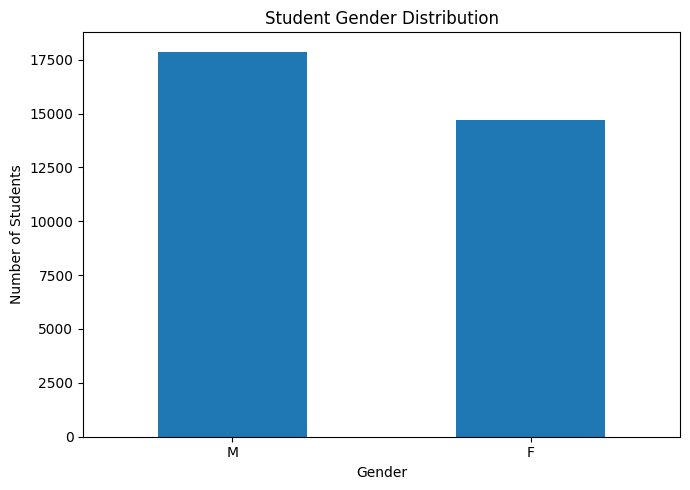

In [41]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind="bar")

plt.title("Student Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

save_figure("gender_distribution.png")

In [42]:
age_counts = (
    student_exploration["age_band"]
    .value_counts()
)

age_counts

,count
age_band,
0-35,22944
35-55,9433
55<=,216


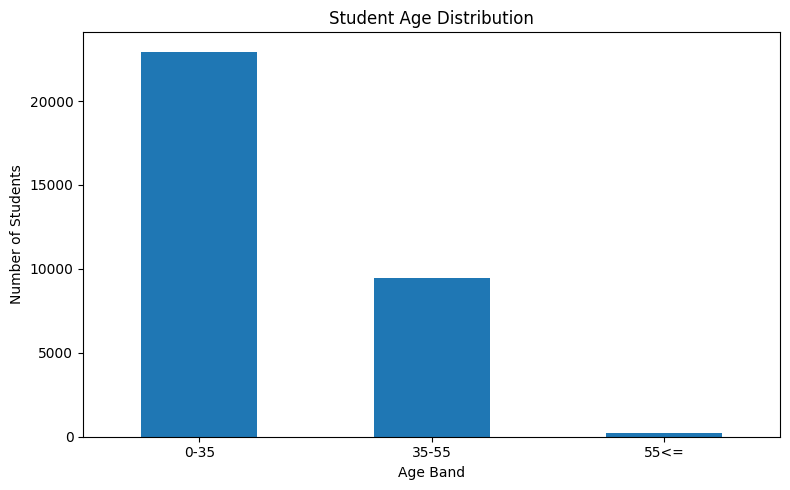

In [43]:
plt.figure(figsize=(8, 5))

age_counts.plot(kind="bar")

plt.title("Student Age Distribution")
plt.xlabel("Age Band")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

save_figure("age_distribution.png")

In [44]:
disability_counts = (
    student_exploration["disability"]
    .value_counts()
)

disability_counts

,count
disability,
N,29429
Y,3164


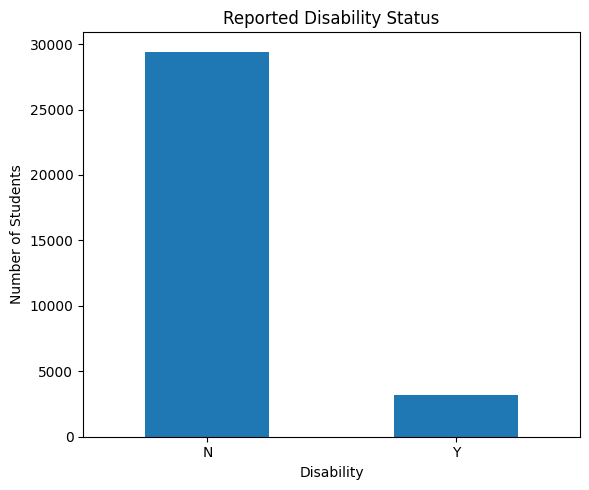

In [45]:
plt.figure(figsize=(6, 5))

disability_counts.plot(kind="bar")

plt.title("Reported Disability Status")
plt.xlabel("Disability")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

save_figure("disability_distribution.png")

In [46]:
student_exploration["num_of_prev_attempts"].describe()

,num_of_prev_attempts
count,32593.000000
mean,0.163225
std,0.479758
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,6.000000


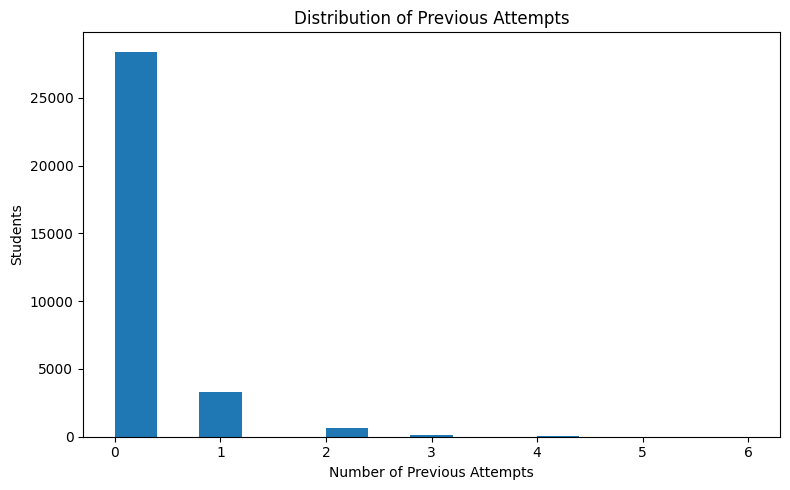

In [47]:
plt.figure(figsize=(8, 5))

plt.hist(
    student_exploration["num_of_prev_attempts"],
    bins=15
)

plt.title("Distribution of Previous Attempts")
plt.xlabel("Number of Previous Attempts")
plt.ylabel("Students")

save_figure("previous_attempts_distribution.png")

In [48]:
student_exploration["studied_credits"].describe()

,studied_credits
count,32593.000000
mean,79.758691
std,41.071900
min,30.000000
25%,60.000000
50%,60.000000
75%,120.000000
max,655.000000


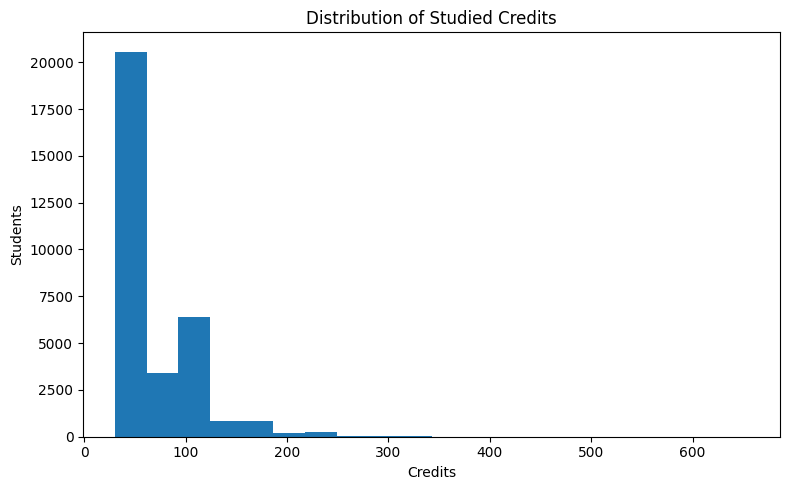

In [49]:
plt.figure(figsize=(8, 5))

plt.hist(
    student_exploration["studied_credits"],
    bins=20
)

plt.title("Distribution of Studied Credits")
plt.xlabel("Credits")
plt.ylabel("Students")

save_figure("studied_credits_distribution.png")

<Figure size 1000x600 with 0 Axes>

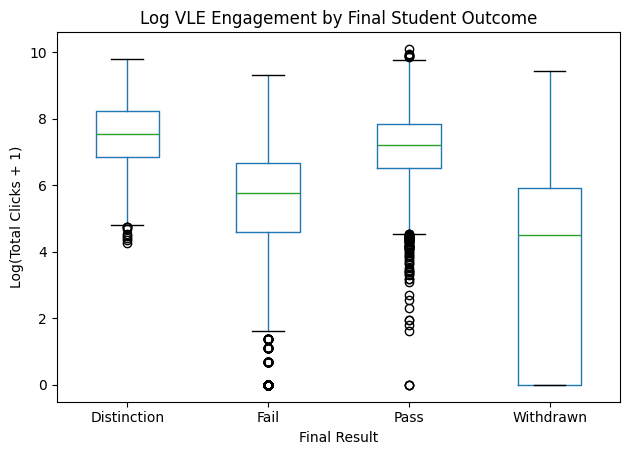

In [50]:
plt.figure(figsize=(10, 6))

student_exploration.boxplot(
    column="log_total_clicks",
    by="final_result",
    grid=False
)

plt.suptitle("")
plt.title("Log VLE Engagement by Final Student Outcome")
plt.xlabel("Final Result")
plt.ylabel("Log(Total Clicks + 1)")

save_figure("engagement_boxplot.png")

Assessment Exploration

In [52]:
# Add module and presentation information to student assessment records

student_assessment_enriched = student_assessment.merge(
    assessments[
        [
            "id_assessment",
            "code_module",
            "code_presentation",
            "assessment_type",
            "date",
            "weight"
        ]
    ],
    on="id_assessment",
    how="left"
)

student_assessment_enriched.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0


In [53]:
student_assessment_enriched.columns.tolist()

['id_assessment',
 'id_student',
 'date_submitted',
 'is_banked',
 'score',
 'code_module',
 'code_presentation',
 'assessment_type',
 'date',
 'weight']

In [54]:
assessment_summary = (
    student_assessment_enriched
    .groupby(
        [
            "code_module",
            "code_presentation",
            "id_student"
        ],
        as_index=False
    )
    .agg(
        assessments_completed=("id_assessment", "count"),
        average_score=("score", "mean"),
        median_score=("score", "median"),
        highest_score=("score", "max"),
        lowest_score=("score", "min")
    )
)

assessment_summary.head()

,code_module,code_presentation,id_student,assessments_completed,average_score,median_score,highest_score,lowest_score
0,AAA,2013J,11391,5,82.0,82.0,85.0,78.0
1,AAA,2013J,28400,5,66.4,68.0,70.0,60.0
2,AAA,2013J,31604,5,76.0,74.0,88.0,71.0
3,AAA,2013J,32885,5,54.4,63.0,75.0,30.0
4,AAA,2013J,38053,5,68.0,69.0,79.0,50.0


In [55]:
student_exploration = student_exploration.merge(
    assessment_summary,
    on=[
        "code_module",
        "code_presentation",
        "id_student"
    ],
    how="left"
)

In [56]:
assessment_columns = [
    "assessments_completed",
    "average_score",
    "median_score",
    "highest_score",
    "lowest_score"
]

student_exploration[assessment_columns] = (
    student_exploration[assessment_columns]
    .fillna(0)
)

In [57]:
student_exploration[assessment_columns].describe()

,assessments_completed,average_score,median_score,highest_score,lowest_score
count,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000
mean,5.335870,57.646621,58.230141,68.559844,44.097260
std,4.326009,32.926518,33.359689,38.272697,30.004943
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,43.000000,43.000000,54.000000,11.000000
50%,5.000000,70.571429,71.000000,87.000000,52.000000
75%,9.000000,82.400000,82.500000,99.000000,68.000000
max,14.000000,100.000000,100.000000,100.000000,100.000000


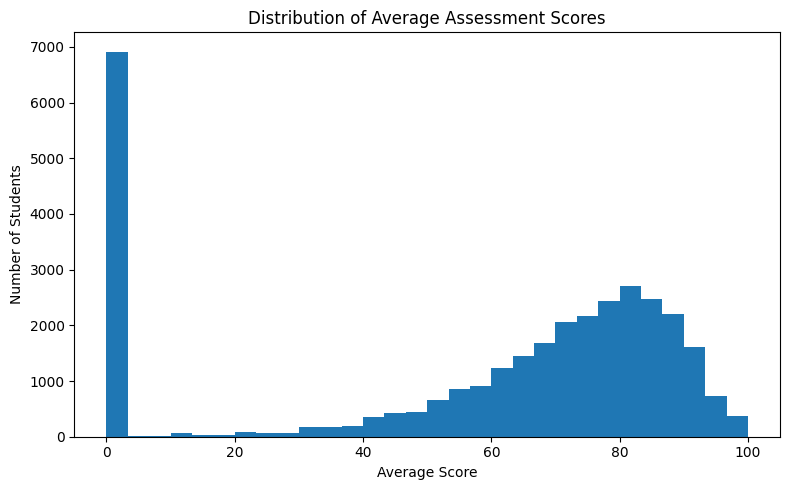

In [58]:
plt.figure(figsize=(8, 5))

plt.hist(
    student_exploration["average_score"],
    bins=30
)

plt.title("Distribution of Average Assessment Scores")
plt.xlabel("Average Score")
plt.ylabel("Number of Students")

save_figure("average_assessment_score_distribution.png")

In [59]:
score_summary = (
    student_exploration
    .groupby("final_result")
    .agg(
        Students=("id_student", "count"),
        Mean_Score=("average_score", "mean"),
        Median_Score=("average_score", "median")
    )
    .round(2)
)

score_summary

,Students,Mean_Score,Median_Score
final_result,,,
Distinction,3024,88.49,89.42
Fail,7052,52.51,61.00
Pass,12361,76.16,77.86
Withdrawn,10156,29.50,0.00


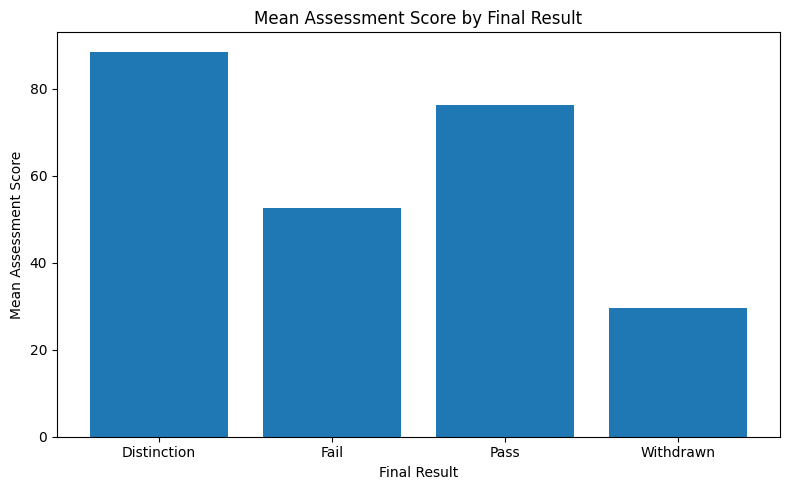

In [60]:
plt.figure(figsize=(8,5))

plt.bar(
    score_summary.index,
    score_summary["Mean_Score"]
)

plt.title("Mean Assessment Score by Final Result")
plt.xlabel("Final Result")
plt.ylabel("Mean Assessment Score")

save_figure("mean_assessment_score_by_outcome.png")

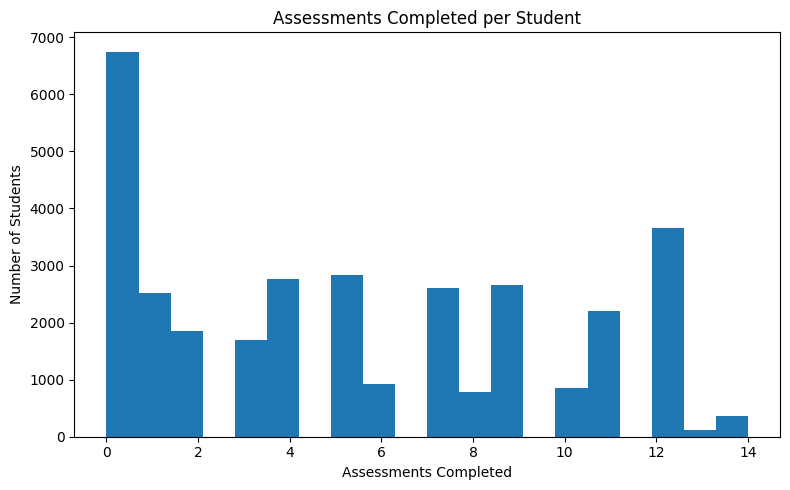

In [61]:
plt.figure(figsize=(8,5))

plt.hist(
    student_exploration["assessments_completed"],
    bins=20
)

plt.title("Assessments Completed per Student")
plt.xlabel("Assessments Completed")
plt.ylabel("Number of Students")

save_figure("assessments_completed_distribution.png")

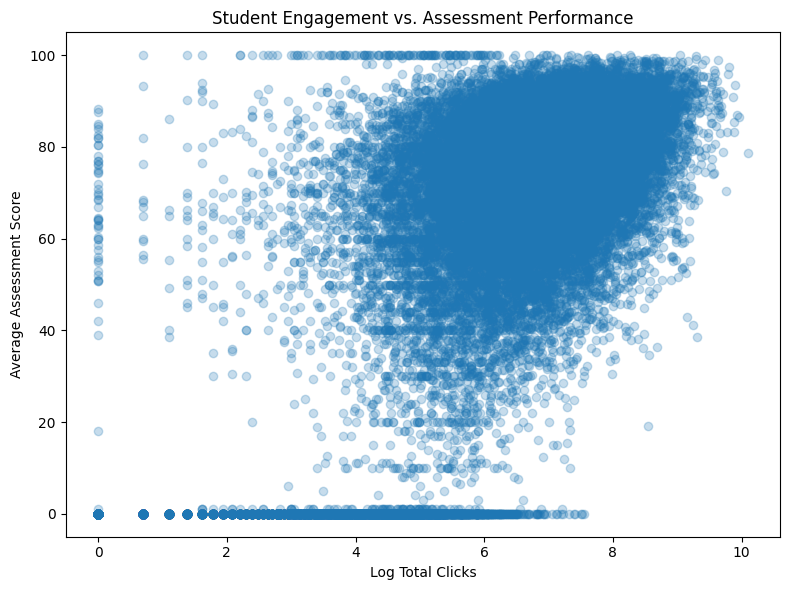

In [62]:
plt.figure(figsize=(8,6))

plt.scatter(
    student_exploration["log_total_clicks"],
    student_exploration["average_score"],
    alpha=0.25
)

plt.title("Student Engagement vs. Assessment Performance")
plt.xlabel("Log Total Clicks")
plt.ylabel("Average Assessment Score")

save_figure("engagement_vs_assessment_score.png")

In [63]:
correlation = student_exploration[
    ["log_total_clicks", "average_score"]
].corr()

correlation

,log_total_clicks,average_score
log_total_clicks,1.000000,0.787838
average_score,0.787838,1.000000


In [64]:
student_exploration["log_total_clicks"].corr(
    student_exploration["average_score"]
)

np.float64(0.7878375892290499)

Registration Analysis

In [65]:
student_registration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [66]:
student_registration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  object 
 1   code_presentation    32593 non-null  object 
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.2+ MB


In [67]:
student_registration["date_registration"].describe()

,date_registration
count,32548.000000
mean,-69.411300
std,49.260522
min,-322.000000
25%,-100.000000
50%,-57.000000
75%,-29.000000
max,167.000000


In [68]:
student_exploration = student_exploration.merge(
    student_registration[
        [
            "code_module",
            "code_presentation",
            "id_student",
            "date_registration",
            "date_unregistration"
        ]
    ],
    on=[
        "code_module",
        "code_presentation",
        "id_student"
    ],
    how="left"
)

In [69]:
student_exploration[
    [
        "date_registration",
        "date_unregistration"
    ]
].isna().sum()

,0
date_registration,45
date_unregistration,22521


In [70]:
registration_summary = (
    student_exploration
    .groupby("final_result")
    .agg(
        Mean_Registration=("date_registration", "mean"),
        Median_Registration=("date_registration", "median"),
        Students=("id_student", "count")
    )
    .round(2)
)

registration_summary

,Mean_Registration,Median_Registration,Students
final_result,,,
Distinction,-65.64,-52.0,3024
Fail,-62.81,-50.0,7052
Pass,-66.71,-53.0,12361
Withdrawn,-78.44,-67.0,10156


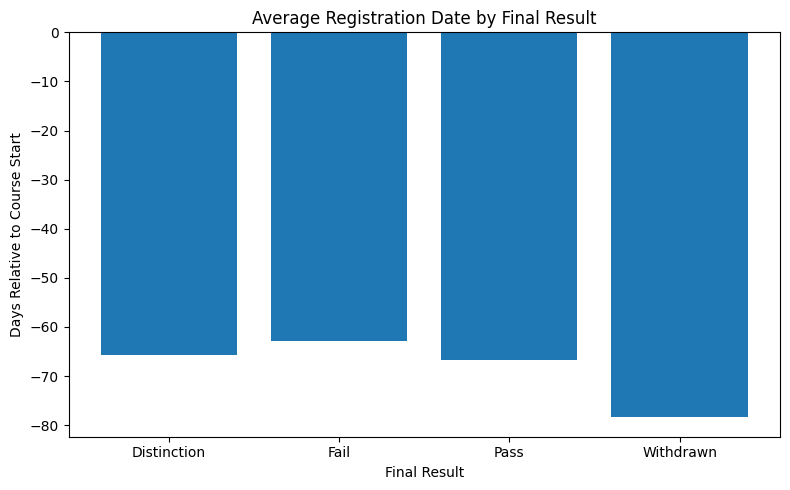

In [71]:
plt.figure(figsize=(8,5))

plt.bar(
    registration_summary.index,
    registration_summary["Mean_Registration"]
)

plt.title("Average Registration Date by Final Result")
plt.xlabel("Final Result")
plt.ylabel("Days Relative to Course Start")

save_figure("registration_by_outcome.png")

In [72]:
student_exploration["withdrew"] = (
    student_exploration["date_unregistration"]
    .notna()
)

student_exploration["withdrew"].value_counts()

,count
withdrew,
False,22521
True,10072


In [73]:
withdrawal_summary = (
    student_exploration
    .groupby("final_result")["withdrew"]
    .mean()
    .sort_values(ascending=False)
)

withdrawal_summary

,withdrew
final_result,
Withdrawn,0.990843
Fail,0.001276
Distinction,0.000000
Pass,0.000000


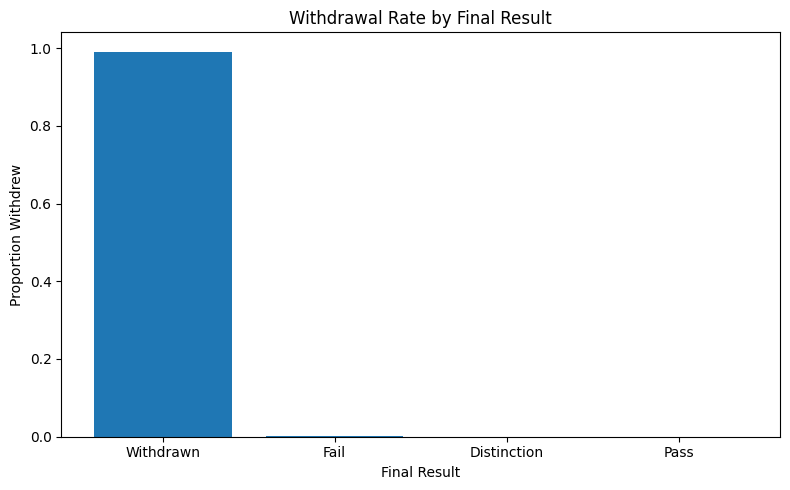

In [74]:
plt.figure(figsize=(8,5))

plt.bar(
    withdrawal_summary.index,
    withdrawal_summary.values
)

plt.title("Withdrawal Rate by Final Result")
plt.xlabel("Final Result")
plt.ylabel("Proportion Withdrew")

save_figure("withdrawal_rate_by_outcome.png")

Feature Relationships

In [79]:
for col in sorted(student_exploration.columns):
    print(col)

age_band
assessments_completed
average_score
code_module
code_presentation
date_registration
date_unregistration
disability
final_result
gender
highest_education
highest_score
id_student
imd_band
log_total_clicks
lowest_score
median_score
num_of_prev_attempts
region
studied_credits
success
total_clicks
withdrew


In [81]:
candidate_features = [
    "studied_credits",
    "num_of_prev_attempts",
    "total_clicks",
    "log_total_clicks",
    "assessments_completed",
    "average_score",
    "median_score",
    "highest_score",
    "lowest_score",
    "date_registration"
]

numeric_features = [
    column
    for column in candidate_features
    if column in student_exploration.columns
]

print("Features included:")
print(numeric_features)

correlation_matrix = (
    student_exploration[numeric_features]
    .corr()
)

correlation_matrix.round(2)

Features included:
['studied_credits', 'num_of_prev_attempts', 'total_clicks', 'log_total_clicks', 'assessments_completed', 'average_score', 'median_score', 'highest_score', 'lowest_score', 'date_registration']


,studied_credits,num_of_prev_attempts,total_clicks,log_total_clicks,assessments_completed,average_score,median_score,highest_score,lowest_score,date_registration
studied_credits,1.00,0.18,-0.04,-0.13,-0.09,-0.15,-0.16,-0.16,-0.12,-0.09
num_of_prev_attempts,0.18,1.00,-0.07,-0.08,-0.05,-0.05,-0.05,-0.04,-0.05,-0.03
total_clicks,-0.04,-0.07,1.00,0.62,0.55,0.44,0.44,0.42,0.40,0.01
log_total_clicks,-0.13,-0.08,0.62,1.00,0.69,0.79,0.79,0.80,0.66,0.12
assessments_completed,-0.09,-0.05,0.55,0.69,1.00,0.68,0.68,0.74,0.48,0.09
average_score,-0.15,-0.05,0.44,0.79,0.68,1.00,0.99,0.97,0.91,0.12
median_score,-0.16,-0.05,0.44,0.79,0.68,0.99,1.00,0.96,0.88,0.12
highest_score,-0.16,-0.04,0.42,0.80,0.74,0.97,0.96,1.00,0.81,0.13
lowest_score,-0.12,-0.05,0.40,0.66,0.48,0.91,0.88,0.81,1.00,0.10
date_registration,-0.09,-0.03,0.01,0.12,0.09,0.12,0.12,0.13,0.10,1.00


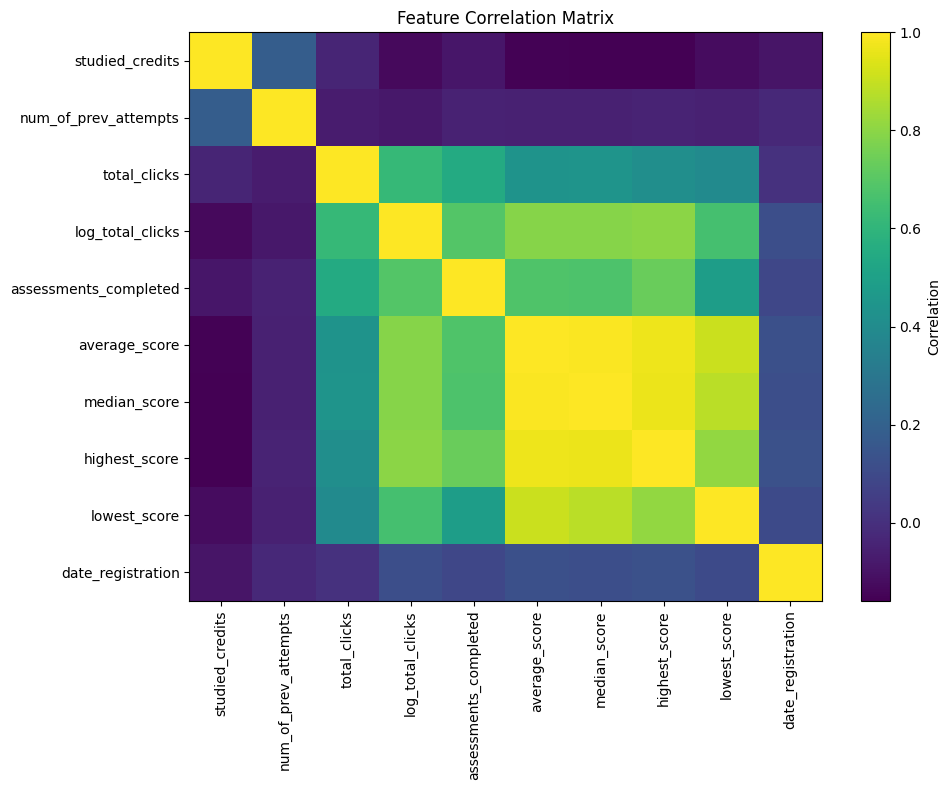

In [82]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")

save_figure("feature_correlation_matrix.png")